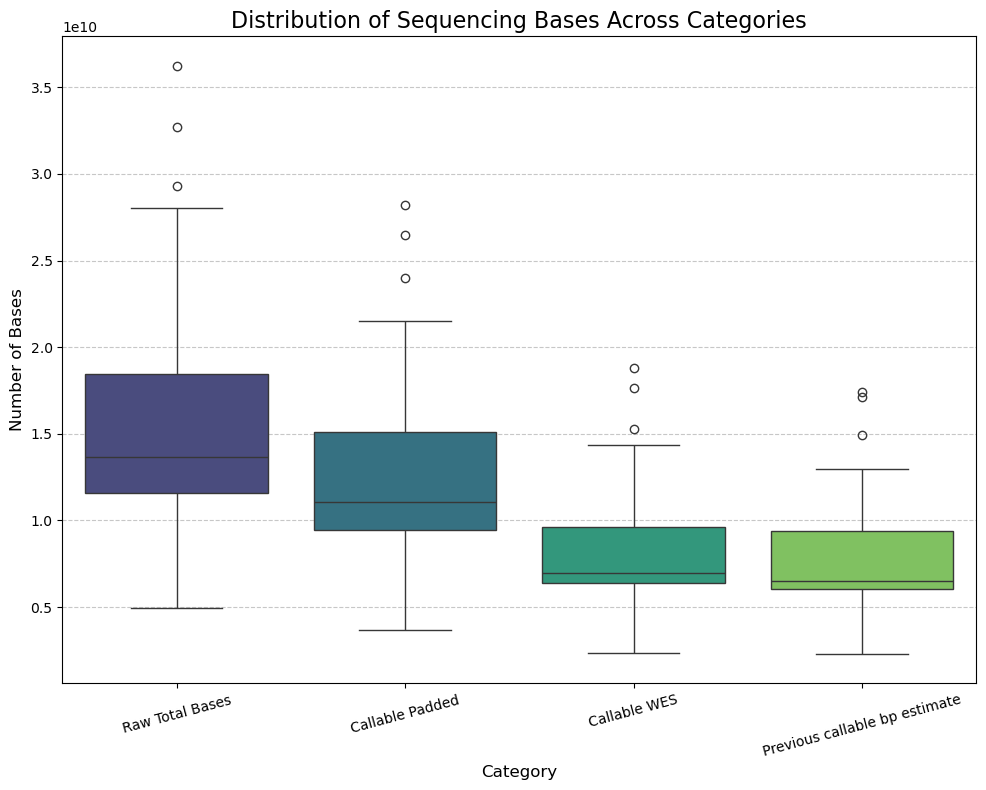

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data 
# Replace these with the actual paths to your two CSV files
file1_path = 'master_list_old_depth.csv'  # Contains sample_id, bases, etc.
file2_path = 'complete_processed_metadata.csv' # Contains sample_id, raw_total_bases, etc.

df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)

# 2. Merge the two files on 'sample_id'
# An 'inner' merge ensures we only plot samples that exist in both files
merged_df = pd.merge(df1, df2, on='sample_id', how='inner')

# 3. Select the columns in the exact order requested:
# left-to-right: raw_total_bases, callable_sequenced_bases_padded, callable_sequenced_bases_wes, bases
columns_to_plot = [
    'raw_total_bases', 
    'callable_sequenced_bases_padded', 
    'callable_sequenced_bases_wes', 
    'bases'
]

# Create a subset dataframe with just these columns
plot_data = merged_df[columns_to_plot]

# Rename the columns to make the plot labels cleaner
plot_data = plot_data.rename(columns={
    'raw_total_bases': 'Raw Total Bases',
    'callable_sequenced_bases_padded': 'Callable Padded',
    'callable_sequenced_bases_wes': 'Callable WES',
    'bases': 'Previous callable bp estimate'
})

# 4. Create the vertical box and whisker plot
plt.figure(figsize=(10, 8))

# Using seaborn for a clean, nicely formatted boxplot
sns.boxplot(data=plot_data, orient='v', palette='viridis')

# Add titles and labels
plt.title('Distribution of Sequencing Bases Across Categories', fontsize=16)
plt.ylabel('Number of Bases', fontsize=12)
plt.xlabel('Category', fontsize=12)

# Rotate x-axis labels slightly if they are overlapping
plt.xticks(rotation=15)

# Add a faint grid for easier reading of the y-axis values
plt.grid(axis='y', linestyle='--', alpha=0.7)

# NOTE: Because base counts are often in the billions (e.g., 17149052815), 
# you might want to uncomment the following line to use a logarithmic scale 
# if the "raw" bases dwarf the others and compress the plot.
# plt.yscale('log')

# Adjust layout to fit everything nicely
plt.tight_layout()

# Display the plot
plt.show()